In [ ]:
!unzip cats_dogs_dataset.zip

Archive:  cats_dogs_dataset.zip
   creating: cats_dogs_dataset/
   creating: cats_dogs_dataset/test/
   creating: cats_dogs_dataset/test/cats/
  inflating: cats_dogs_dataset/test/cats/233.jpg  
  inflating: cats_dogs_dataset/test/cats/234.jpg  
  inflating: cats_dogs_dataset/test/cats/235.jpg  
  inflating: cats_dogs_dataset/test/cats/236.jpg  
  inflating: cats_dogs_dataset/test/cats/237.jpg  
  inflating: cats_dogs_dataset/test/cats/238.jpg  
  inflating: cats_dogs_dataset/test/cats/239.jpg  
  inflating: cats_dogs_dataset/test/cats/24.jpg  
  inflating: cats_dogs_dataset/test/cats/240.jpg  
  inflating: cats_dogs_dataset/test/cats/241.jpg  
  inflating: cats_dogs_dataset/test/cats/242.jpg  
  inflating: cats_dogs_dataset/test/cats/243.jpg  
  inflating: cats_dogs_dataset/test/cats/244.jpg  
  inflating: cats_dogs_dataset/test/cats/245.jpg  
  inflating: cats_dogs_dataset/test/cats/246.jpg  
  inflating: cats_dogs_dataset/test/cats/247.jpg  
  inflating: cats_dogs_dataset/test/cats/2

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable weights before freezing: 30
Trainable weights after freezing: 4
Found 3598 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Epoch 1/30
 93/100 ━━━━━━━━━━━━━━━━━━━━ 2s 300ms/step - accuracy: 0.6092 - loss: 0.6639

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 366ms/step - accuracy: 0.6886 - loss: 0.6004 - val_accuracy: 0.8600 - val_loss: 0.4189
Epoch 2/30
  1/100 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.7812 - loss: 0.5321

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.7668 - loss: 0.5063 - val_accuracy: 0.8375 - val_loss: 0.4165
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 263ms/step - accuracy: 0.7857 - loss: 0.4667 - val_accuracy: 0.8725 - val_loss: 0.3329
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8005 - loss: 0.4457 - val_accuracy: 0.8925 - val_loss: 0.3199
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 265ms/step - accuracy: 0.8140 - loss: 0.4236 - val_accuracy: 0.8900 - val_loss: 0.2976
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8221 - loss: 0.4007 - val_accuracy: 0.8800 - val_loss: 0.3080
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 270ms/step - accuracy: 0.8187 - loss: 0.4019 - val_accuracy: 0.9075 - val_loss: 0.2696
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.8462 - loss: 0.3607 - val_accuracy: 0.9000 - val_loss: 0.2780
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 268ms/step - accuracy: 0.8202 - loss: 0.3863 - val_accurac

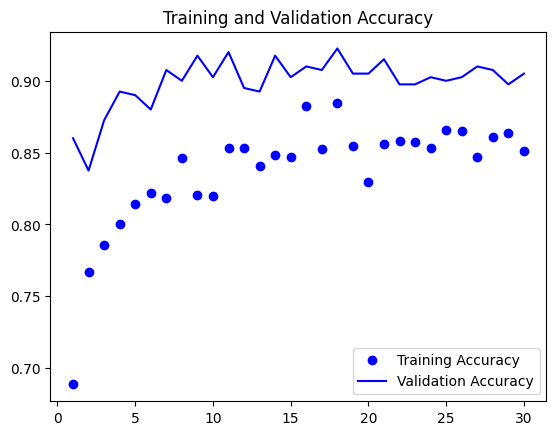

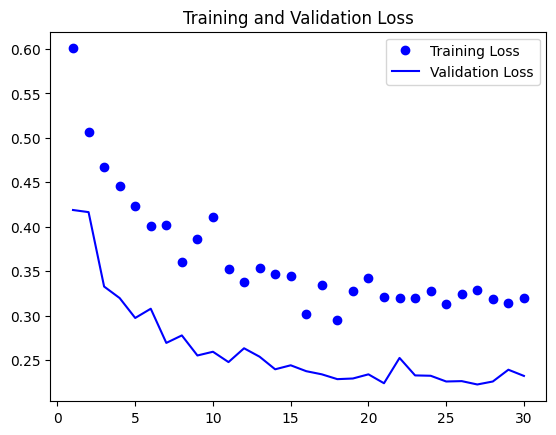

In [ ]:
# Transfer Learning with VGG16 + Data Augmentation

from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Load pretrained VGG16 convolution base
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

# Build model
model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

# Freeze convolution base
print("Trainable weights before freezing:", len(model.trainable_weights))
conv_base.trainable = False
print("Trainable weights after freezing:", len(model.trainable_weights))

# Dataset directories
train_dir="/content/cats_dogs_dataset/train/"
validation_dir="/content/cats_dogs_dataset/validation/"


# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation data should NOT be augmented
validation_datagen = ImageDataGenerator(rescale=1./255)


# Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)


# Compile model
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=2e-5),
    metrics=['accuracy']
)


# Train model
history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=50
)


# Plot results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1,len(acc)+1)

plt.plot(epochs, acc, 'bo', label='Training Accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()